##Week 3 Coding Practice: Plotting and Visualization
####DSCI-D590: Applied Data Science, Owen Randolph, 9/10/2025

###A Brief matplotlib API Primer

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create a dataset list
data = np.arange(10)
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

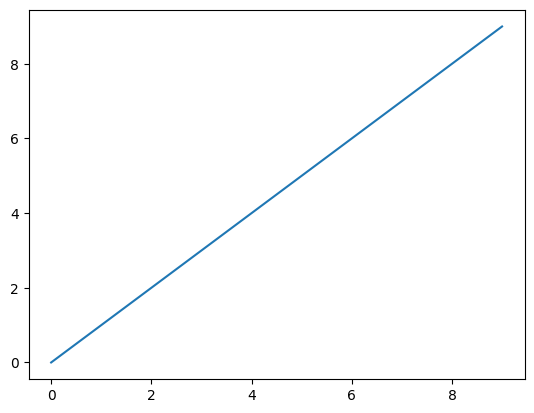

In [3]:
# Plot Data as a line
plt.plot(data)

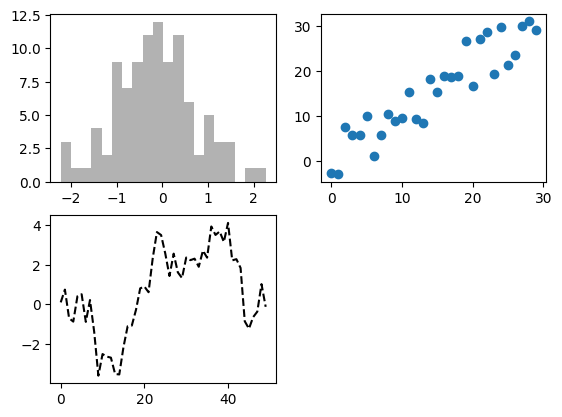

In [4]:
# Create three charts and plot random data using three different styles of visualization
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed");
ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3);
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30));

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

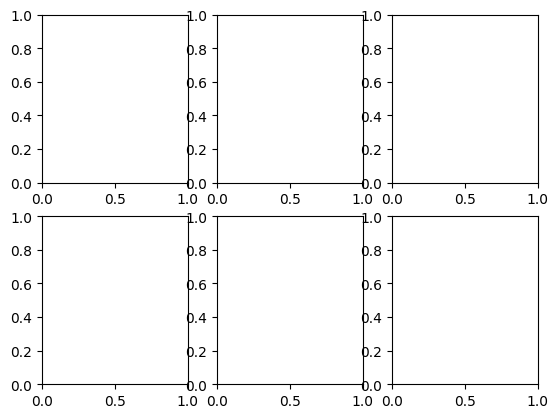

In [5]:
# Create a grid of subplots
fig, axes = plt.subplots(2, 3)
axes

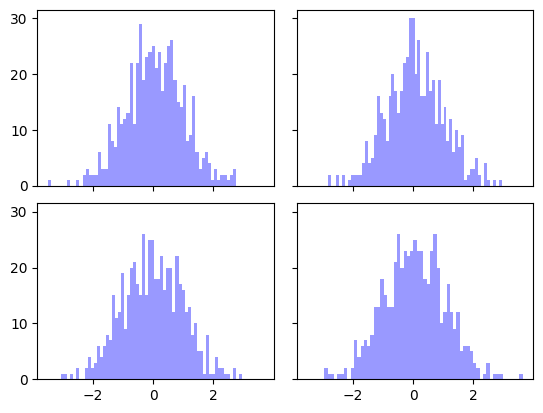

In [6]:
#Testing the spacing parameters with standard spacing for vertical and horizontal spacing
fig, axes = plt. subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.standard_normal(550), bins=60,
                        color = "blue", alpha=0.4)
fig.subplots_adjust(wspace=.1, hspace=.1)

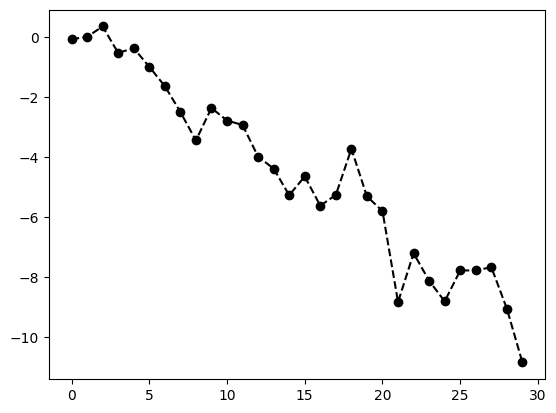

In [7]:
# Plotting a line graph with point markers
ax = fig.add_subplot()

plt.plot(np.random.standard_normal(30).cumsum(), color="black", linestyle='dashed', marker = "o");

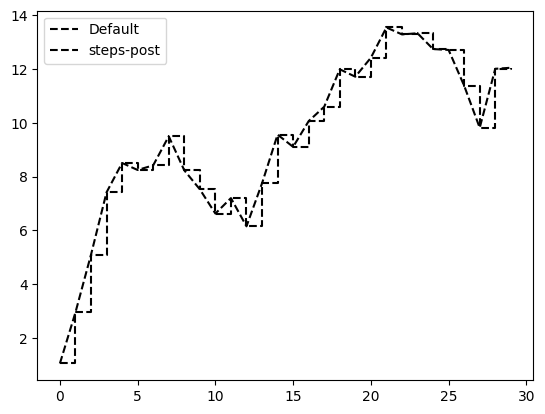

In [8]:
# Add steps to a line graph at point intervals
fig = plt.figure()
ax = fig.add_subplot()
data = np.random.standard_normal(30).cumsum()
ax.plot(data, color = "black", linestyle="dashed", label="Default");
ax.plot(data, color="black", linestyle="dashed",
        drawstyle="steps-post", label="steps-post");
ax.legend()

Text(0.5, 1.0, 'My first matplotlib plot')

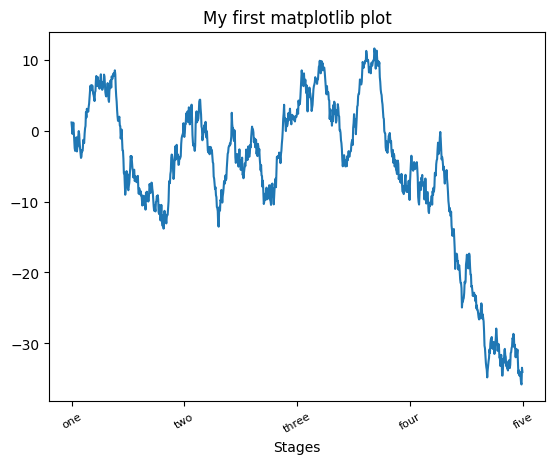

In [9]:
# Ticks, Labels, and Legends
# Create a line graph of a random walk with custom ticks
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum());
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(["one", "two", "three", "four", "five"],
                            rotation = 30, fontsize = 8)
ax.set_xlabel("Stages")
ax.set_title("My first matplotlib plot")

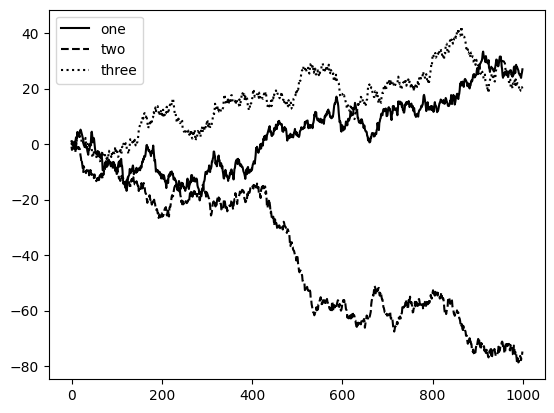

In [10]:
# Adding Legend
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color='black', label="one");
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dashed", label="two");
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dotted", label="three");
ax.legend()

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

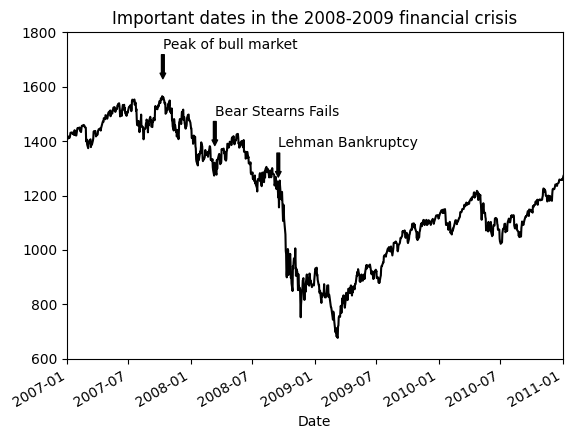

In [16]:
# Demonstrating use of annotation and axes limits
import pandas as pd
from datetime import datetime
fig, ax = plt.subplots()
data = pd.read_csv("spx.csv", index_col=0, parse_dates = True)
spx = data["SPX"]

spx.plot(ax=ax, color="black")

crisis_data = [
    (datetime(2007, 10, 11), "Peak of bull market"),
    (datetime(2008, 3, 12), "Bear Stearns Fails"),
    (datetime(2008, 9, 15), "Lehman Bankruptcy")
]

for date, label in crisis_data:
    ax.annotate(label, xy=(date, spx.asof(date) + 75),
                xytext=(date, spx.asof(date) + 225),
                arrowprops=dict(facecolor="black", headwidth=4, width=2,
                                headlength=4),
                horizontalalignment="left", verticalalignment="top")

#Zoom in on 2007-2010
ax.set_xlim(["1/1/2007", "1/1/2011"])
ax.set_ylim([600, 1800])

ax.set_title("Important dates in the 2008-2009 financial crisis")

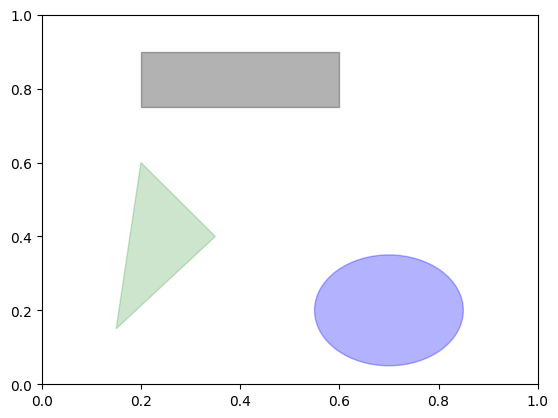

In [22]:
# Patches
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color = 'black', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color="blue", alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]], color="green", alpha=0.2)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon);

In [23]:
# Save Plots to File
fig.savefig("figpath.svg")

###Plotting with pandas and seaborn

<Axes: >

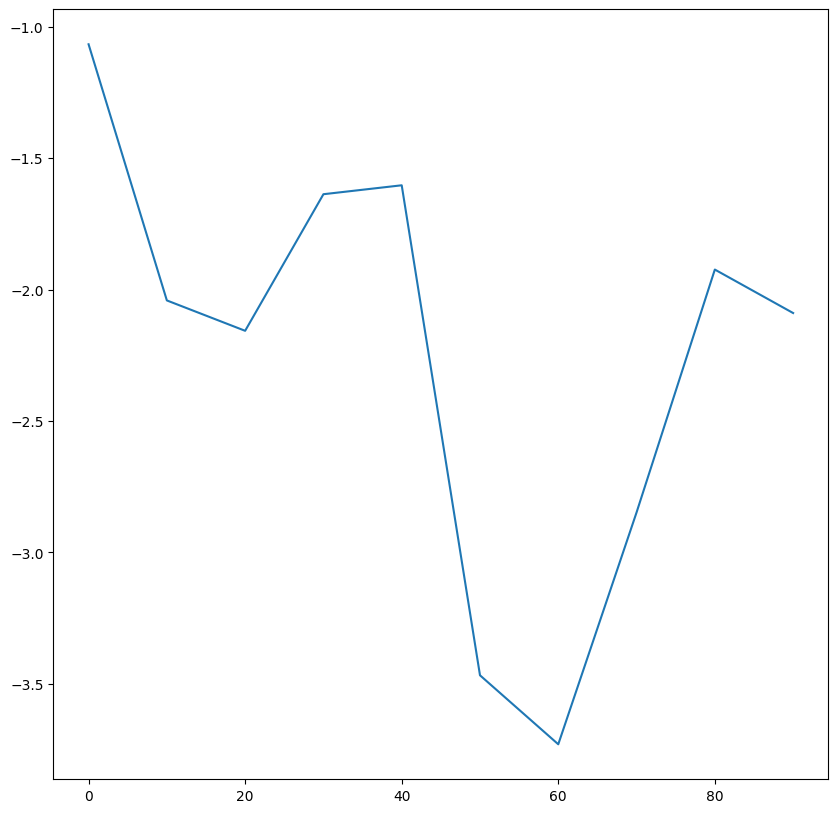

In [33]:
# Plot a pandas Series
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))

s.plot()

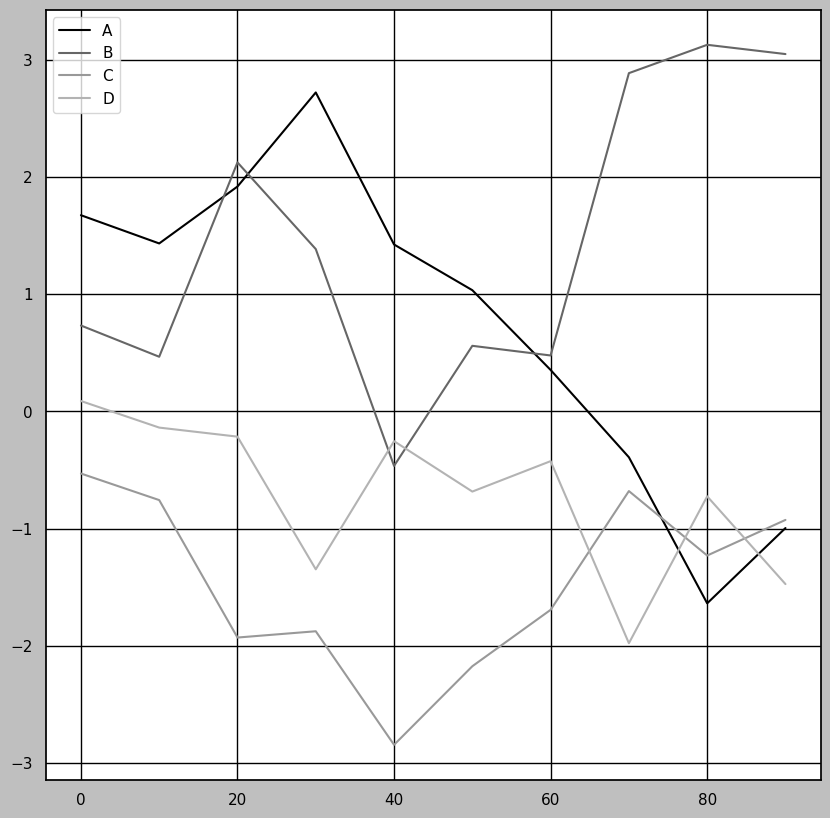

In [80]:
# Plot a pandas DataFrame
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                  columns=["A", "B", "C", "D"],
                  index=np.arange(0, 100, 10))
plt.style.use('grayscale')
df.plot();

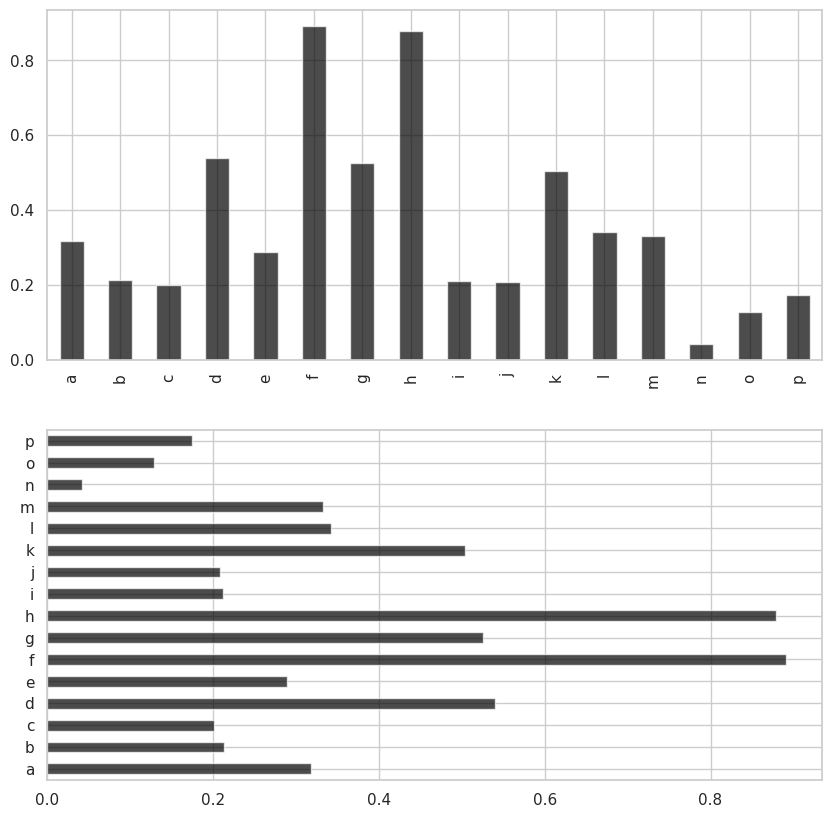

In [79]:
# Bar Charts
# Create bar plots using Series data
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))
data.plot.bar(ax=axes[0], color="black", alpha = 0.7)
data.plot.barh(ax=axes[1], color="black", alpha = 0.7);

In [40]:
# Create DataFrame
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=["one", "two", "three", "four", "five", "six"],
                  columns=pd.Index(["A", "B", "C", "D"], name="Genus"))
df

Genus,A,B,C,D
one,0.859101,0.676305,0.053869,0.870725
two,0.169902,0.851898,0.817206,0.914271
three,0.910133,0.914836,0.827349,0.573676
four,0.544713,0.637733,0.757179,0.961621
five,0.556798,0.392216,0.973222,0.500367
six,0.675339,0.446275,0.186145,0.906945


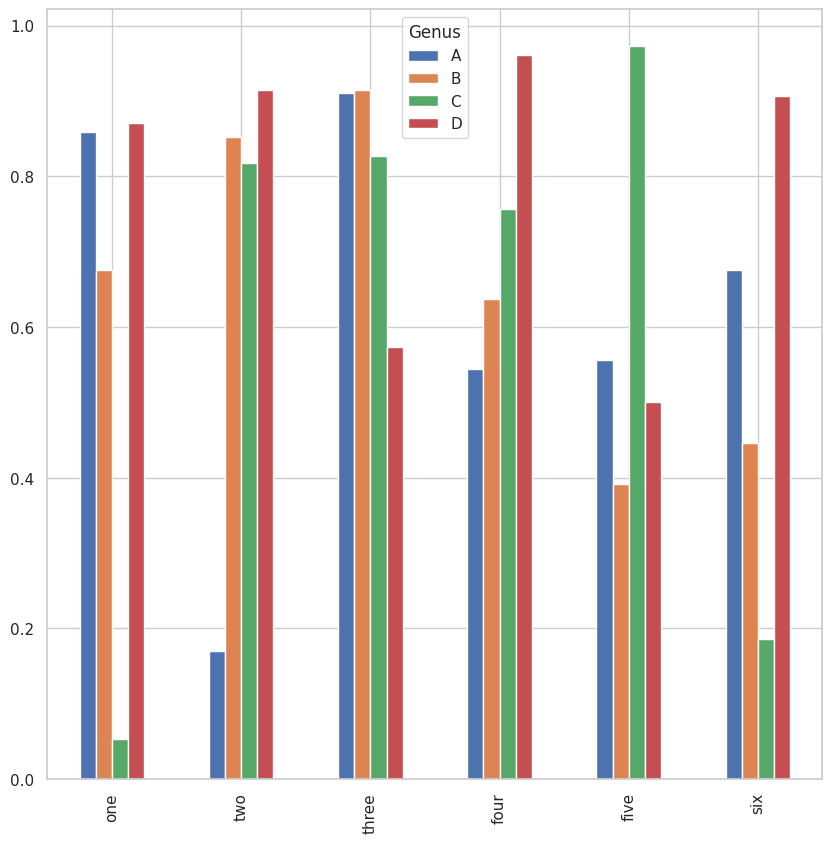

In [78]:
# Show bar plot of DateFrame
df.plot.bar();

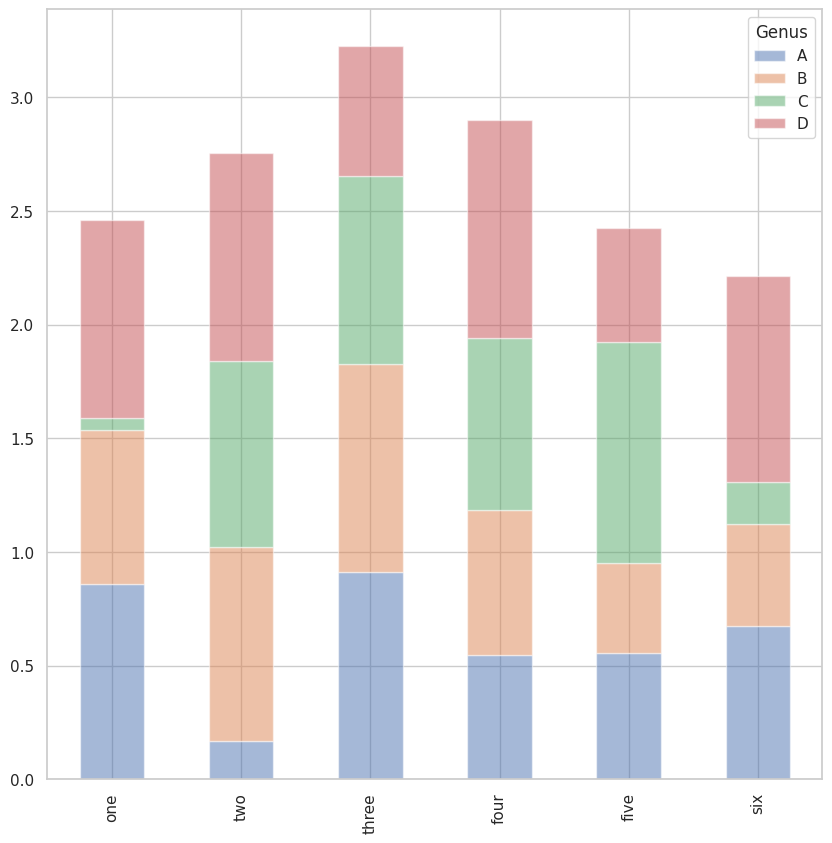

In [77]:
# Create stacked bar chart with DataFrame
df.plot.bar(stacked=True, alpha=0.5);

In [45]:
# Load Tips dataset
tips = pd.read_csv("tips.csv")

In [46]:
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [48]:
# Compute a frequency table from day and size columns
party_counts = pd.crosstab(tips['day'], tips["size"])
party_counts = party_counts.reindex(index=["Thur", "Fri", "Sat", "Sun"])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,1,48,4,5,1,3
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1


In [56]:
# Remove single diners and 6-top parties
party_counts = party_counts.loc[:, 2:5]

In [57]:
# Normalize to sum to 1
party_pcts = party_counts.div(party_counts.sum(axis="columns"), axis="index")
party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


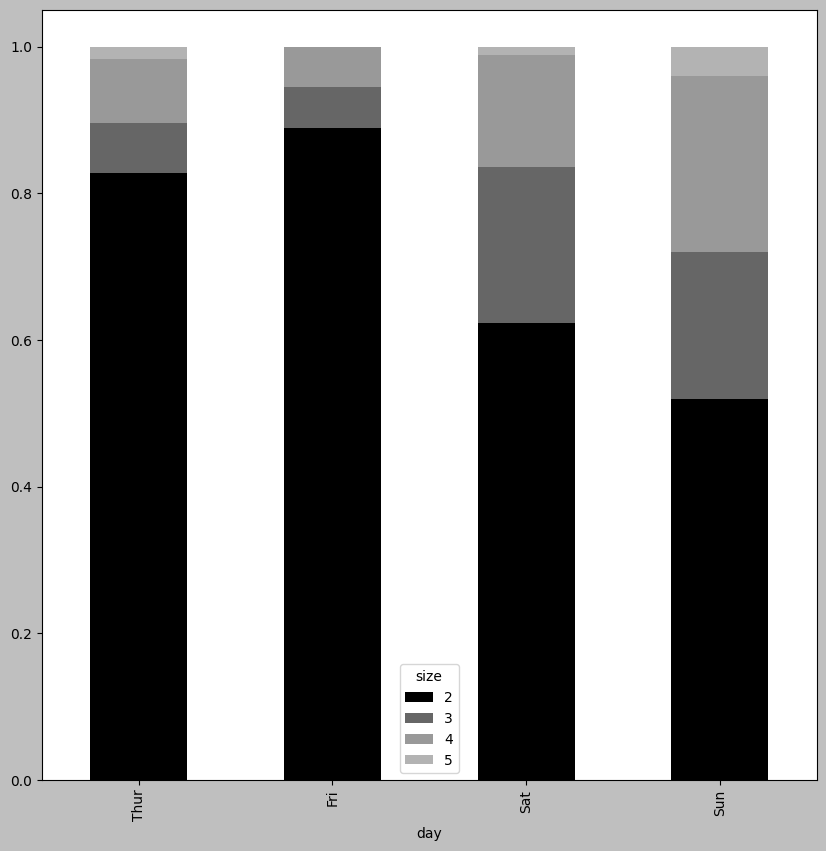

In [58]:
# Plot Stacked Bar Chart
party_pcts.plot.bar(stacked=True);

In [59]:
# Import Seaborn
import seaborn as sns

In [63]:
# Add a tip percentage column
tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips['tip'])

In [64]:
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


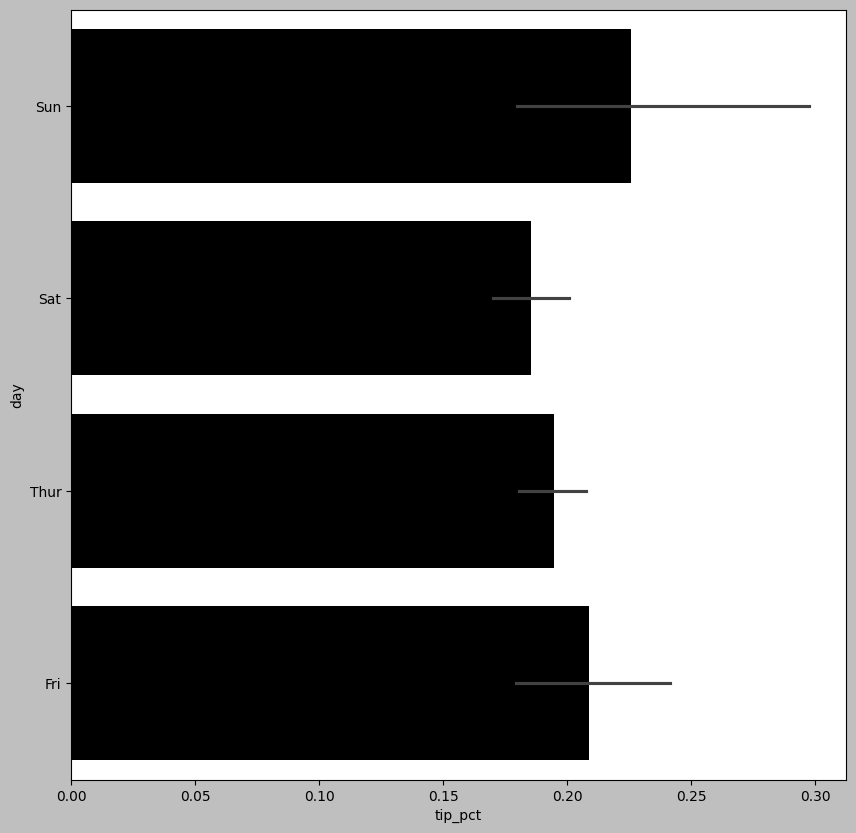

In [66]:
# Plot average tip percentage by day as a horizontal bar chart with error bars
sns.barplot(x="tip_pct", y="day", data=tips, orient='h');

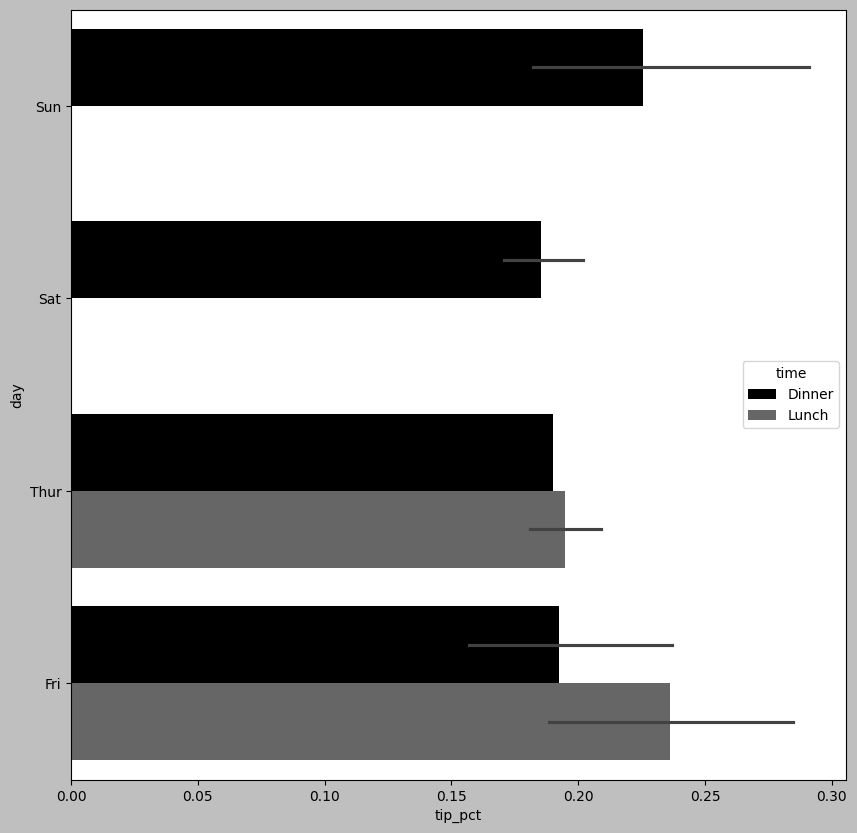

In [68]:
# Plot tip average percentages with lunch included
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h");

In [69]:
# Change plot appearance
sns.set(style="whitegrid")

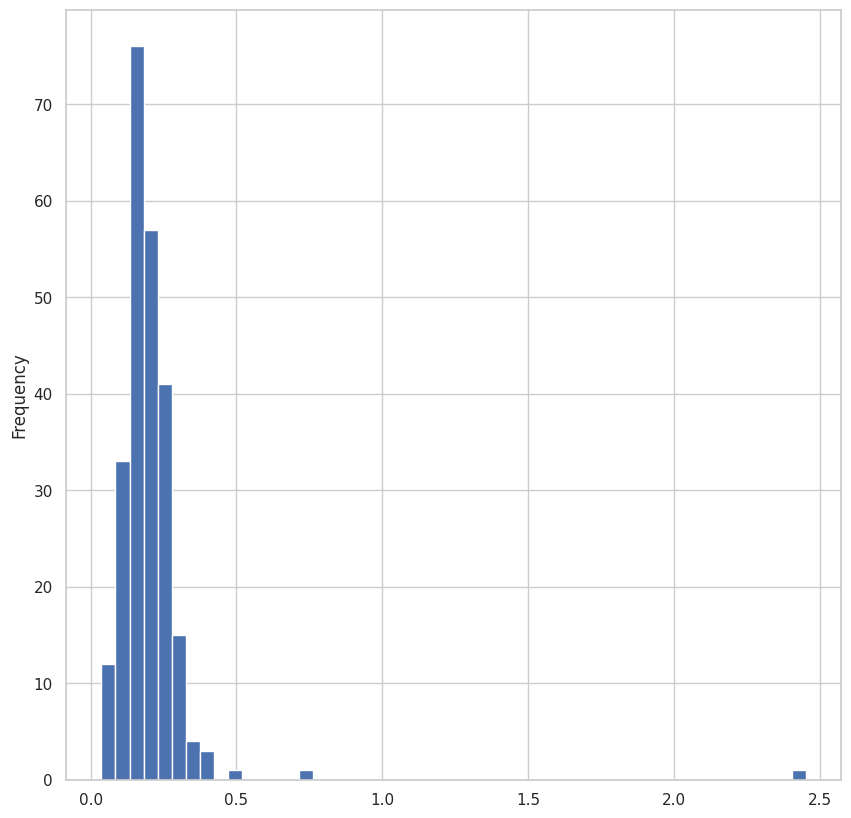

In [71]:
# Histograms and Density Plots
# Plot tip percentages as a 50-bin histogram
tips["tip_pct"].plot.hist(bins=50);

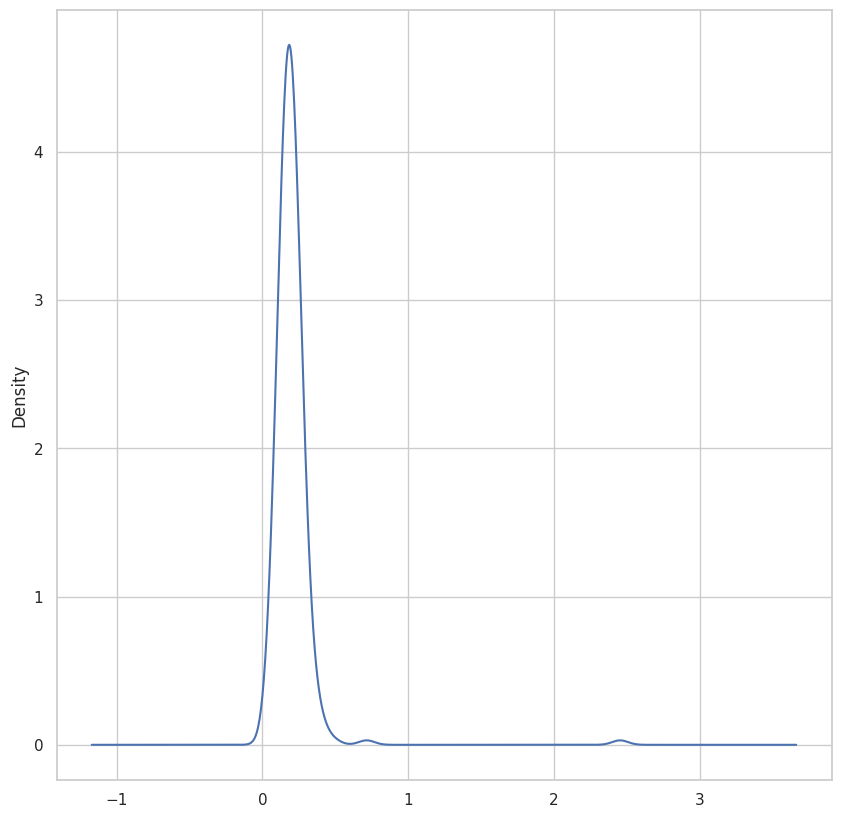

In [76]:
# Plot a density plot for tips data
tips["tip_pct"].plot.density();

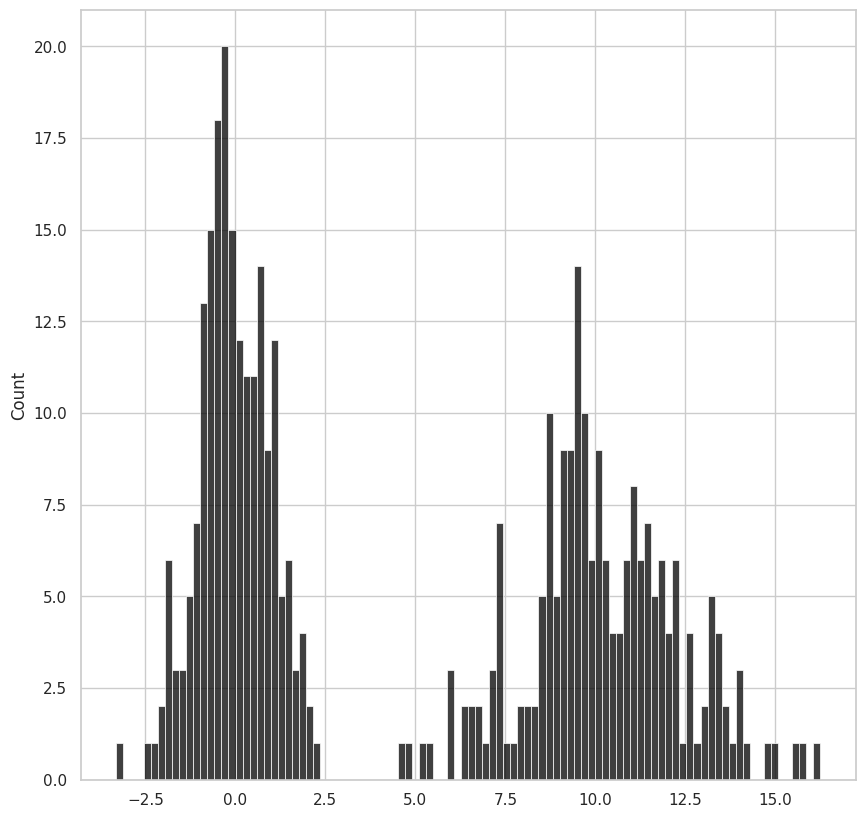

In [75]:
# Plot histogram and density plot simultaneously
comp1 = np.random.standard_normal(200)
comp2 = 10 + 2 * np.random.standard_normal(200)
values = pd.Series(np.concatenate([comp1, comp2]))
sns.histplot(values, bins=100, color = "black");

In [81]:
# Scatter or Point Plots
# Read in Macro data
macro = pd.read_csv("macrodata.csv")

In [83]:
# Create a DataFrame with four attributes, computing log differences
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
trans_data = np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


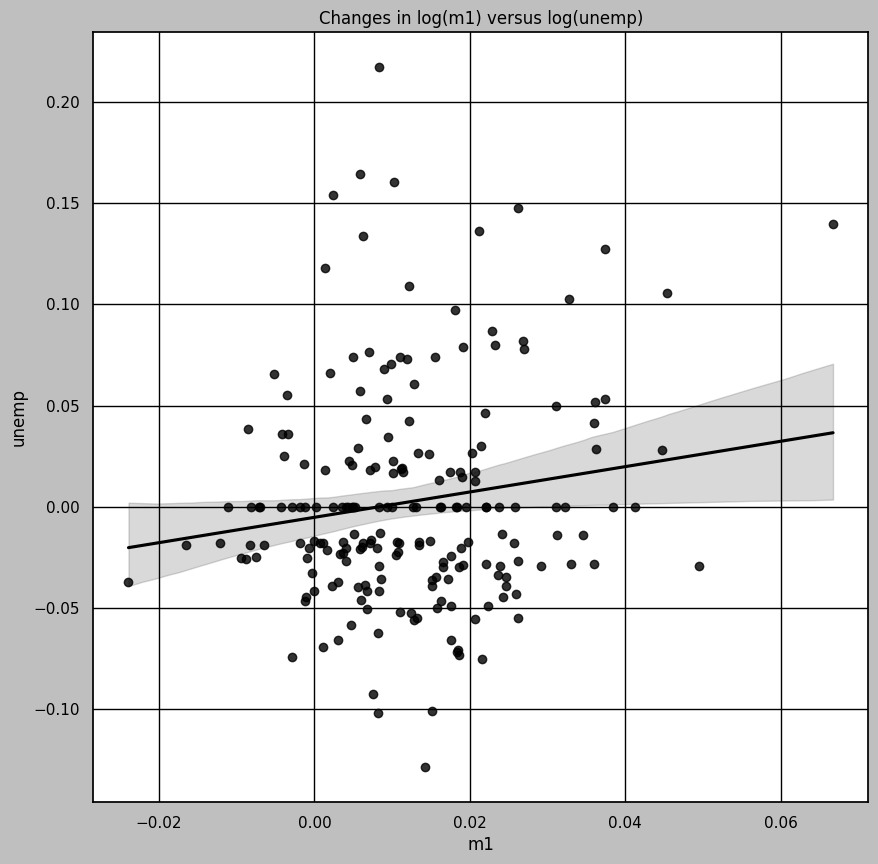

In [85]:
# Create scatter plot with linear regression line of best fit
ax = sns.regplot(x="m1", y="unemp", data=trans_data)
ax.set_title("Changes in log(m1) versus log(unemp)");

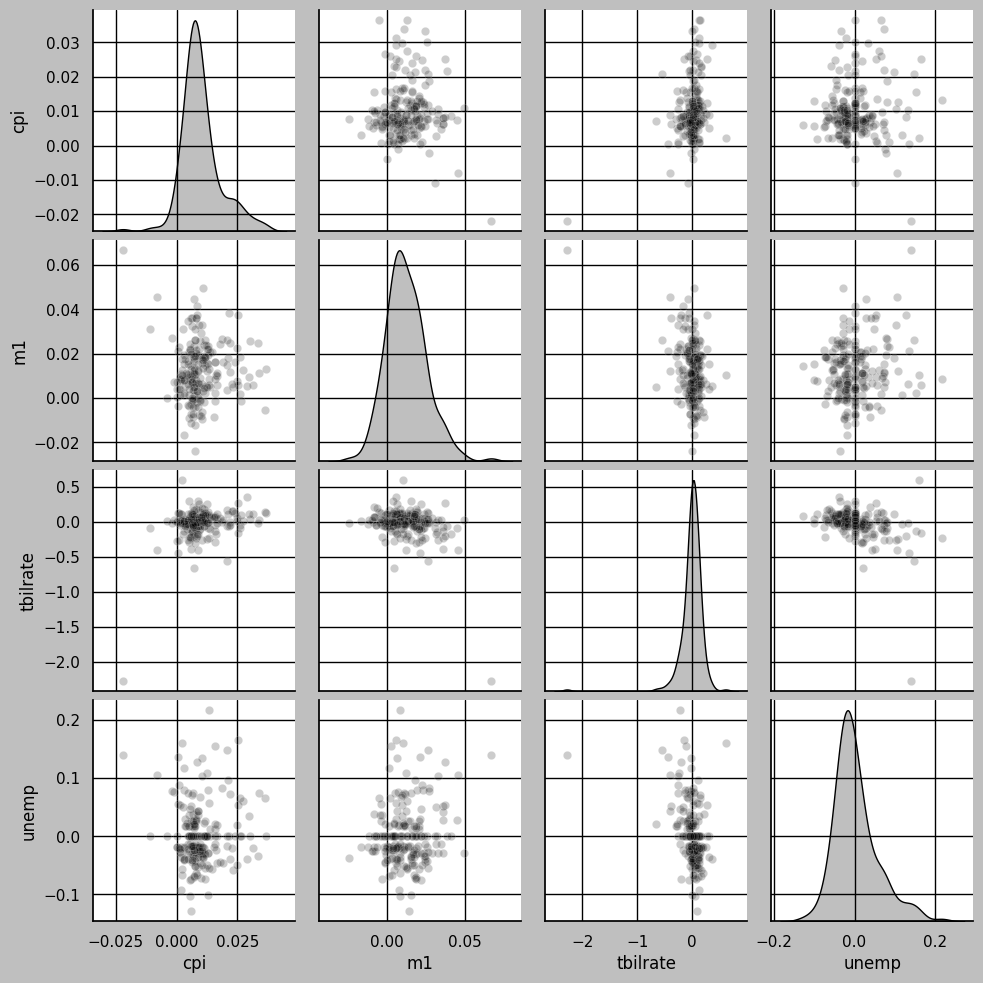

In [86]:
# show pair plot matrix for each of the variable combinations
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha": 0.2})

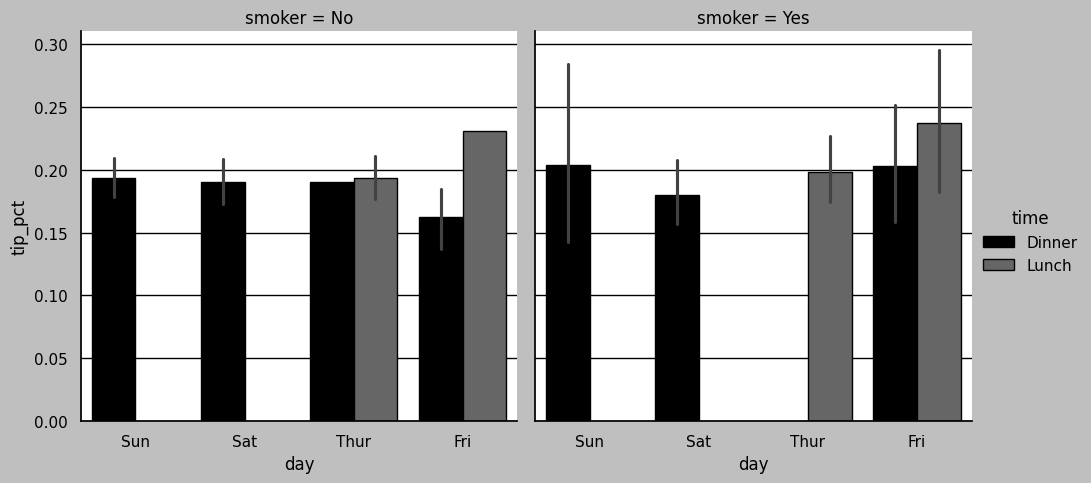

In [89]:
# Facet Grids and Categorical Data
# Display tip percentage by day, meal type, and by smoker or non
sns.catplot(x="day", y="tip_pct", hue = "time", col="smoker", kind = "bar", data=tips[tips.tip_pct < 1]);

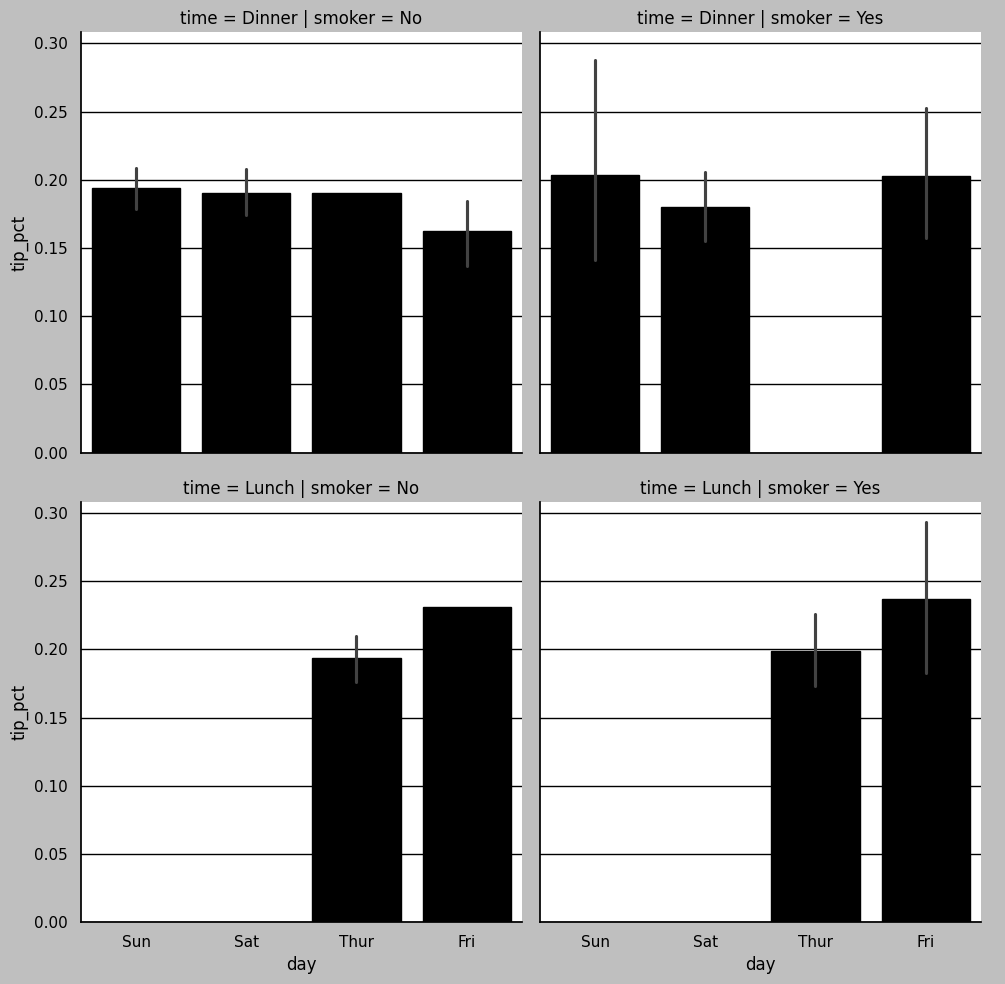

In [91]:
# Re=orient to show plot grouping by meal type
sns.catplot(x="day", y="tip_pct", row="time", col="smoker", kind= "bar", data=tips[tips.tip_pct < 1]);

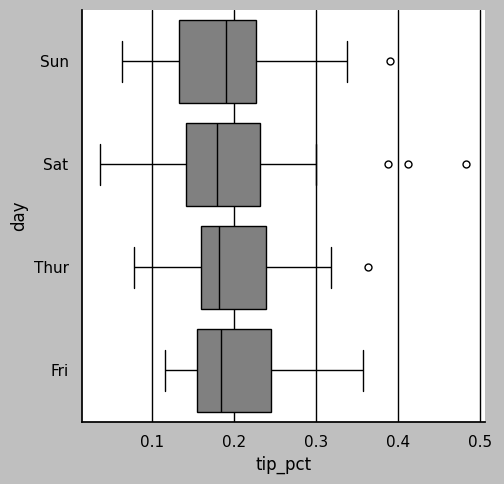

In [94]:
# Create Box Plots by day and tip percentage
sns.catplot(x="tip_pct", y="day", kind="box", data=tips[tips.tip_pct < 0.5], boxprops=dict(facecolor = "grey", edgecolor="black"))